# Rectified Flow on MNIST (Pixel Space)

This notebook implements and trains a Rectified Flow model in pixel space and compares it with DDPM/DDIM.

## Overview
- **Rectified Flow**: Learns straight-line paths from noise to data
- **Key Difference**: Predicts velocity v(x,t) instead of noise ε
- **Training**: Minimize E[||v(x_t, t) - (x_1 - x_0)||²]
- **Sampling**: ODE integration using Euler or Heun methods
- **Dataset**: MNIST (28x28 grayscale images)
- **Evaluation**: Compare convergence, quality, and speed vs DDPM/DDIM

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
import matplotlib.pyplot as plt
import numpy as np
import time

from rectified_flow import RectifiedFlow
from rectified_flow.callbacks import RFSamplingCallback, FlowProgressCallback, RFQualityEvaluator
from ddpm import DDPM

# Set random seed for reproducibility
pl.seed_everything(42)

Seed set to 42


42

## 1. Data Loading

Load MNIST dataset and normalize to [-1, 1] range.

In [ ]:
# Transform: normalize to [-1, 1] range
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Maps [0, 1] -> [-1, 1]
])

# Load MNIST
train_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

val_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# Create dataloaders
batch_size = 256
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 60000
Validation samples: 10000
Batch size: 128


## 2. Model Configuration

Configure Rectified Flow hyperparameters:
- Uses same UNet architecture as DDPM for fair comparison
- Predicts velocity instead of noise
- 1000 timesteps for training
- 50 steps for inference (Euler/Heun integration)

In [4]:
# Model hyperparameters
model = RectifiedFlow(
    in_channels=1,              # Grayscale images
    model_channels=64,          # Base UNet channels
    channel_mult=(1, 2, 4),     # Channel multipliers per level
    num_res_blocks=2,           # Residual blocks per level
    num_timesteps=1000,         # Timesteps for training
    lr=2e-4,                    # Learning rate
    num_inference_steps=50,     # Default ODE integration steps
    dropout=0.1,                # Dropout probability
    num_heads=4                 # Attention heads
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Model parameters: 14.16M


## 3. Training Setup

Setup callbacks for:
- Periodic sample generation (Euler vs Heun)
- Flow process visualization
- Model checkpointing
- Learning rate monitoring

In [5]:
# Callbacks
callbacks = [
    # Generate samples every 10 epochs
    RFSamplingCallback(
        num_samples=16,
        log_every_n_epochs=10,
        save_dir='../plots/rectified_flow',
        num_steps=50
    ),
    
    # Visualize flow progress at specific epochs
    FlowProgressCallback(
        num_samples=8,
        num_steps_to_show=10,
        save_dir='../plots/rectified_flow',
        log_at_epochs=[5, 10, 25, 50, 100, 200]
    ),
    
    # Save best model
    ModelCheckpoint(
        dirpath='../data/saved_models/rectified_flow',
        filename='rf_mnist_{epoch:03d}_{val_loss:.4f}',
        monitor='val_loss',
        mode='min',
        save_top_k=3
    ),
    
    # Monitor learning rate
    LearningRateMonitor(logging_interval='epoch')
]

# Trainer
trainer = pl.Trainer(
    max_epochs=100,
    accelerator='gpu',
    devices=1,
    callbacks=callbacks,
    log_every_n_steps=50,
    gradient_clip_val=1.0,
    precision='16-mixed' if torch.cuda.is_available() else 32
)

print(f"Training device: {trainer.accelerator}")
print(f"Number of epochs: {trainer.max_epochs}")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training device: <pytorch_lightning.accelerators.cuda.CUDAAccelerator object at 0x74b13e42cc10>
Number of epochs: 100


## 4. Train Model

Train the Rectified Flow model. This will:
1. Learn to predict velocity v(x,t) = x_1 - x_0
2. Generate samples periodically to monitor progress
3. Save the best models based on validation loss

In [6]:
# Train
trainer.fit(model, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 5090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/xgeoadmin/miniconda3/envs/cuda-ml/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name  | Type | Params | Mode 
---------------------------------------
0 | model | UNet | 14.2 M | train
---------------------------------------
14.2 M    Trainable params
0         Non-trainable params
14.2 M    Total params
56.637    Total estimated model params size (MB)
288       Modules in train mode
0         Modules i

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/xgeoadmin/miniconda3/envs/cuda-ml/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 5. Load Best Model and Generate Samples

In [7]:
# Load best checkpoint
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path}")
model = RectifiedFlow.load_from_checkpoint(best_model_path)
model.eval()
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

Loading best model from: /home/xgeoadmin/Nazar/ucu-genai-cv-2025/data/saved_models/rectified_flow/rf_mnist_epoch=030_val_loss=0.1661.ckpt


## 6. Sample Quality Comparison

Compare Euler vs Heun integration methods at different step counts.


Generating samples with 10 steps...

Generating samples with 25 steps...

Generating samples with 50 steps...

Generating samples with 100 steps...


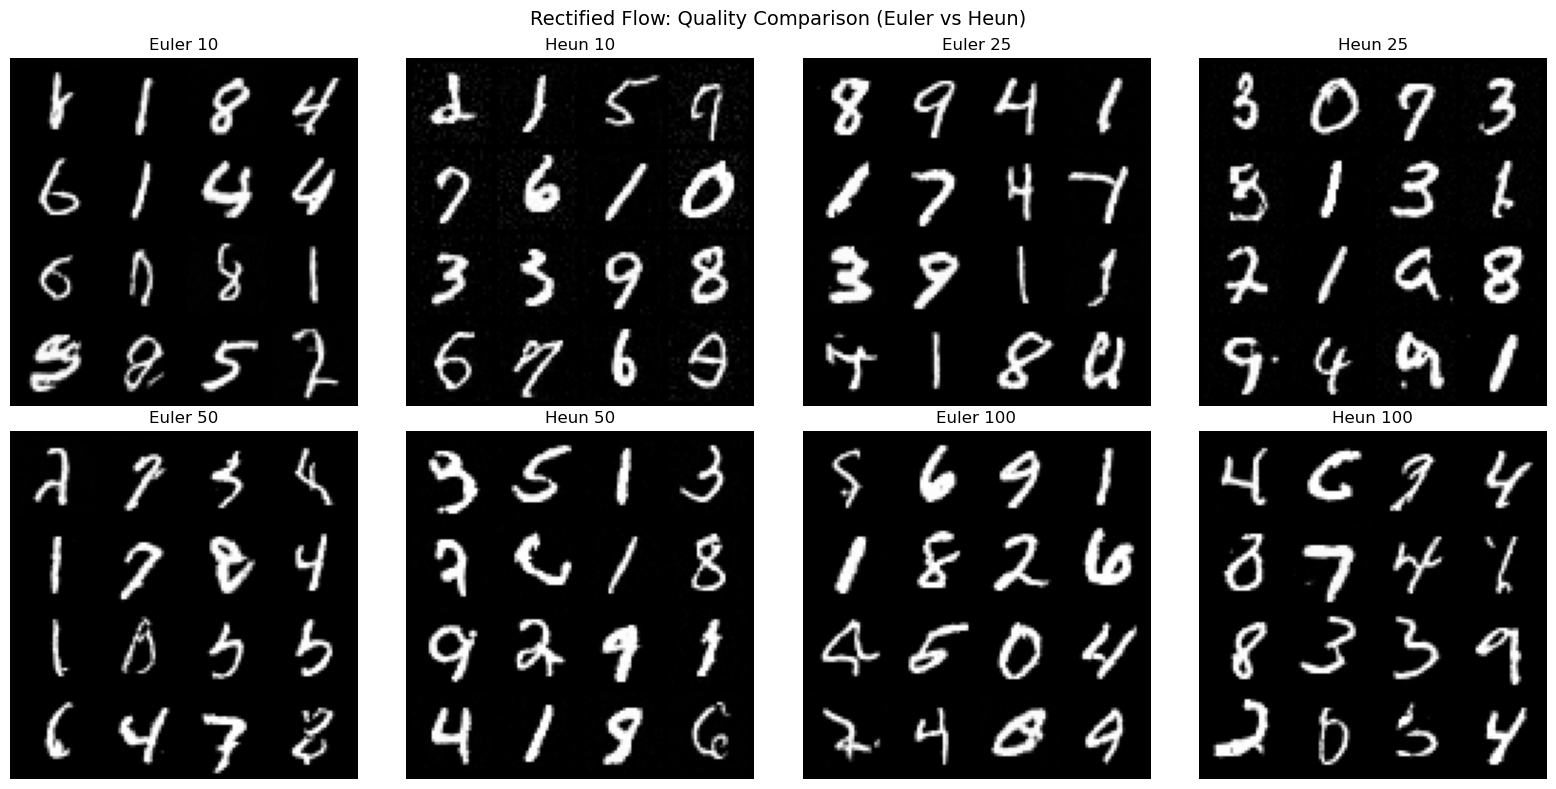

In [8]:
# Generate samples with different methods and step counts
step_counts = [10, 25, 50, 100]
num_samples = 64

samples_dict = {}

for steps in step_counts:
    print(f"\nGenerating samples with {steps} steps...")
    
    # Euler method
    with torch.no_grad():
        euler_samples = model.sample(
            num_samples=num_samples,
            method='euler',
            num_inference_steps=steps
        )
    samples_dict[f'Euler {steps}'] = euler_samples
    
    # Heun method
    with torch.no_grad():
        heun_samples = model.sample(
            num_samples=num_samples,
            method='heun',
            num_inference_steps=steps
        )
    samples_dict[f'Heun {steps}'] = heun_samples

# Plot comparison
num_methods = len(samples_dict)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, samples) in enumerate(samples_dict.items()):
    grid = torchvision.utils.make_grid(
        samples[:16].cpu(), nrow=4, normalize=True, value_range=(-1, 1)
    )
    axes[idx].imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Rectified Flow: Quality Comparison (Euler vs Heun)', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/rectified_flow/rf_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualize Flow Process

Show how images evolve from noise to data along straight-line paths.

Generating flow process visualization...


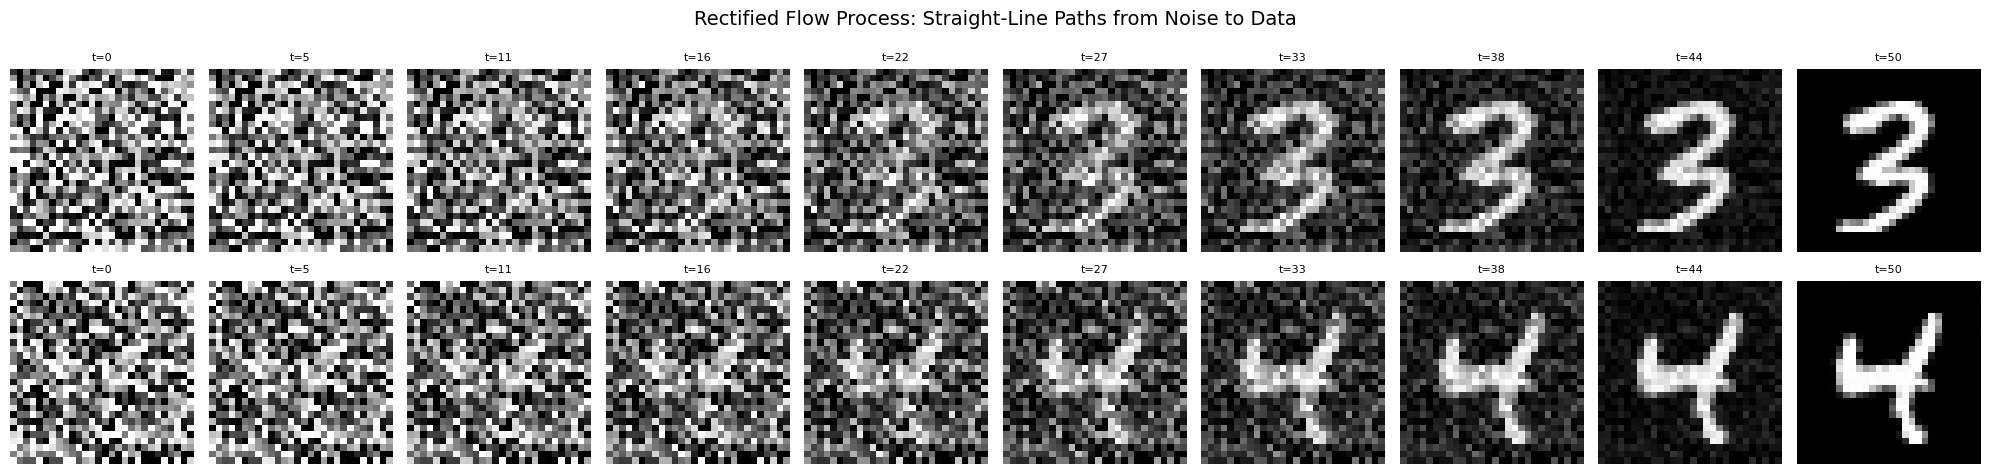

In [9]:
# Generate with all intermediate steps
print("Generating flow process visualization...")
with torch.no_grad():
    final_euler, euler_steps = model.sample(
        num_samples=1,
        method='euler',
        num_inference_steps=50,
        return_all_steps=True
    )
    
    final_heun, heun_steps = model.sample(
        num_samples=1,
        method='heun',
        num_inference_steps=50,
        return_all_steps=True
    )

# Select timesteps to visualize
num_steps_to_show = 10
euler_indices = np.linspace(0, len(euler_steps) - 1, num_steps_to_show, dtype=int)
heun_indices = np.linspace(0, len(heun_steps) - 1, num_steps_to_show, dtype=int)

fig, axes = plt.subplots(2, num_steps_to_show, figsize=(20, 5))

# Euler progression
for i, idx in enumerate(euler_indices):
    img = euler_steps[idx][0].cpu()
    img = (img + 1) / 2  # Denormalize
    axes[0, i].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title(f't={idx}', fontsize=8)

# Heun progression
for i, idx in enumerate(heun_indices):
    img = heun_steps[idx][0].cpu()
    img = (img + 1) / 2
    axes[1, i].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    axes[1, i].set_title(f't={idx}', fontsize=8)

axes[0, 0].set_ylabel('Euler\n(50 steps)', fontsize=10, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('Heun\n(50 steps)', fontsize=10, rotation=0, ha='right', va='center')

plt.suptitle('Rectified Flow Process: Straight-Line Paths from Noise to Data', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/rectified_flow/rf_flow_process.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Speed Comparison

Compare inference speed between Euler and Heun methods at different step counts.

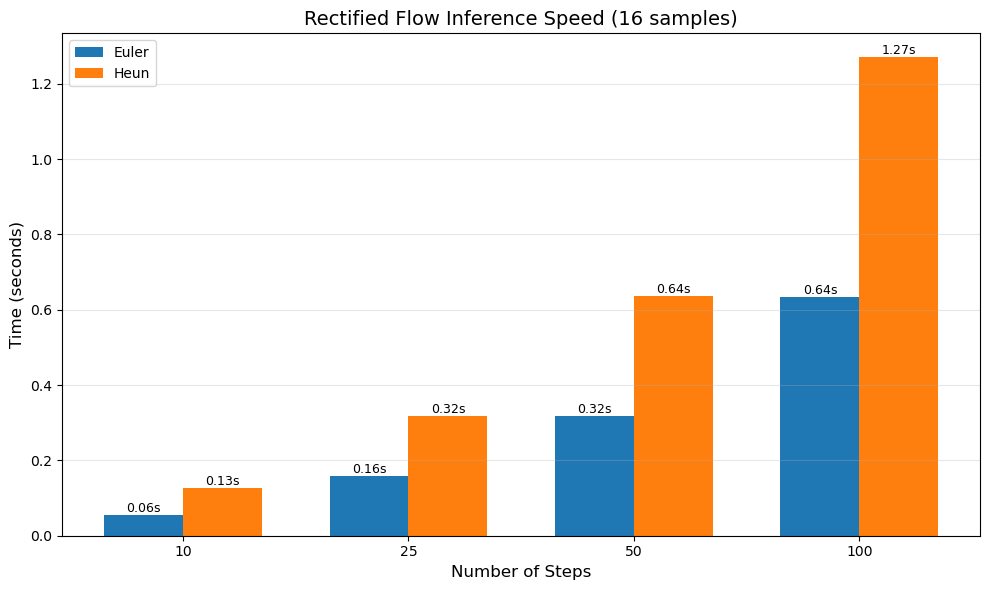


Speed Summary:
  10 steps: Euler=0.06s, Heun=0.13s
  25 steps: Euler=0.16s, Heun=0.32s
  50 steps: Euler=0.32s, Heun=0.64s
  100 steps: Euler=0.64s, Heun=1.27s


In [10]:
# Benchmark different methods
num_samples_benchmark = 16
step_counts = [10, 25, 50, 100]

results = {'Euler': {}, 'Heun': {}}

for steps in step_counts:
    # Euler
    start = time.time()
    with torch.no_grad():
        _ = model.sample(num_samples=num_samples_benchmark, method='euler', num_inference_steps=steps)
    results['Euler'][steps] = time.time() - start
    
    # Heun
    start = time.time()
    with torch.no_grad():
        _ = model.sample(num_samples=num_samples_benchmark, method='heun', num_inference_steps=steps)
    results['Heun'][steps] = time.time() - start

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x = np.arange(len(step_counts))
width = 0.35

euler_times = [results['Euler'][s] for s in step_counts]
heun_times = [results['Heun'][s] for s in step_counts]

bars1 = ax.bar(x - width/2, euler_times, width, label='Euler', color='#1f77b4')
bars2 = ax.bar(x + width/2, heun_times, width, label='Heun', color='#ff7f0e')

ax.set_xlabel('Number of Steps', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title(f'Rectified Flow Inference Speed ({num_samples_benchmark} samples)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(step_counts)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add time labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../plots/rectified_flow/rf_speed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\nSpeed Summary:")
for steps in step_counts:
    print(f"  {steps} steps: Euler={results['Euler'][steps]:.2f}s, Heun={results['Heun'][steps]:.2f}s")

## 9. Compare with DDPM/DDIM

Load a trained DDPM model and compare quality and speed.

Loading DDPM model from: ../data/saved_models/ddpm/ddpm_mnist_epoch=098_val_loss=0.0198.ckpt

Generating DDPM samples (1000 steps)...
Generating DDIM samples (50 steps)...
Generating RF Euler samples (50 steps)...


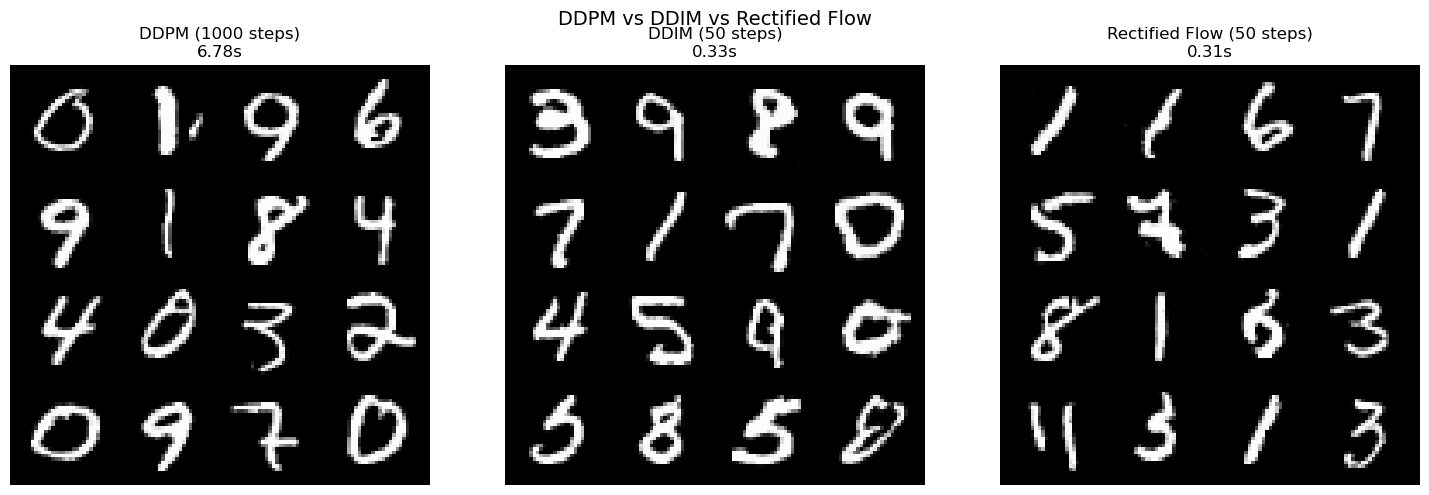


Speed Comparison (16 samples):
  DDPM (1000 steps): 6.78s
  DDIM (50 steps):   0.33s (20.30x faster)
  RF Euler (50 steps): 0.31s (21.98x faster)


In [11]:
# Load DDPM model (if available)
import glob
ddpm_checkpoints = glob.glob('../data/saved_models/ddpm/*.ckpt')

if ddpm_checkpoints:
    ddpm_checkpoint = sorted(ddpm_checkpoints)[-1]  # Get latest
    print(f"Loading DDPM model from: {ddpm_checkpoint}")
    
    ddpm_model = DDPM.load_from_checkpoint(ddpm_checkpoint)
    ddpm_model.eval()
    ddpm_model = ddpm_model.to('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Generate samples
    print("\nGenerating DDPM samples (1000 steps)...")
    start = time.time()
    with torch.no_grad():
        ddpm_samples = ddpm_model.sample(num_samples=16, method='ddpm')
    ddpm_time = time.time() - start
    
    print("Generating DDIM samples (50 steps)...")
    start = time.time()
    with torch.no_grad():
        ddim_samples = ddpm_model.sample(num_samples=16, method='ddim', num_inference_steps=50)
    ddim_time = time.time() - start
    
    print("Generating RF Euler samples (50 steps)...")
    start = time.time()
    with torch.no_grad():
        rf_samples = model.sample(num_samples=16, method='euler', num_inference_steps=50)
    rf_time = time.time() - start
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # DDPM
    grid = torchvision.utils.make_grid(ddpm_samples.cpu(), nrow=4, normalize=True, value_range=(-1, 1))
    axes[0].imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
    axes[0].set_title(f'DDPM (1000 steps)\n{ddpm_time:.2f}s', fontsize=12)
    axes[0].axis('off')
    
    # DDIM
    grid = torchvision.utils.make_grid(ddim_samples.cpu(), nrow=4, normalize=True, value_range=(-1, 1))
    axes[1].imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
    axes[1].set_title(f'DDIM (50 steps)\n{ddim_time:.2f}s', fontsize=12)
    axes[1].axis('off')
    
    # Rectified Flow
    grid = torchvision.utils.make_grid(rf_samples.cpu(), nrow=4, normalize=True, value_range=(-1, 1))
    axes[2].imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
    axes[2].set_title(f'Rectified Flow (50 steps)\n{rf_time:.2f}s', fontsize=12)
    axes[2].axis('off')
    
    plt.suptitle('DDPM vs DDIM vs Rectified Flow', fontsize=14)
    plt.tight_layout()
    plt.savefig('../plots/rectified_flow/ddpm_vs_rf_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nSpeed Comparison (16 samples):")
    print(f"  DDPM (1000 steps): {ddpm_time:.2f}s")
    print(f"  DDIM (50 steps):   {ddim_time:.2f}s ({ddpm_time/ddim_time:.2f}x faster)")
    print(f"  RF Euler (50 steps): {rf_time:.2f}s ({ddpm_time/rf_time:.2f}x faster)")
else:
    print("No DDPM checkpoint found. Train DDPM first for comparison.")

## Summary

This notebook demonstrated:
1. **Rectified Flow Training**: Learned straight-line velocity fields
2. **ODE Integration**: Euler and Heun methods for sampling
3. **Quality Evaluation**: Compared sample quality at different step counts
4. **Speed Comparison**: Measured inference time
5. **DDPM/DDIM Comparison**: Evaluated against diffusion models

**Key Findings**:
- Rectified Flow learns simpler straight-line paths vs curved diffusion paths
- Euler method is faster but Heun offers better accuracy
- Comparable quality to DDIM with similar number of steps
- Training can be more stable due to simpler objective